# Credit Risk Intelligence — experiment walkthrough

An executed review notebook for the V2 review of the retained V1 fitted model. Training is performed by `python -m src.models.train`; this notebook reads its real artifacts and explores only training data before showing frozen test evidence. Educational decision support; Taiwan, 2005, not automated lending.

**Reading order:** source validation → training EDA → historical features → model selection → held-out evidence → explanations → limitations.

In [1]:
from pathlib import Path
import sys, json, zipfile
import pandas as pd
from IPython.display import display, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src/config.py').exists())
sys.path.insert(0, str(ROOT))
from src.config import RAW_FEATURES, TARGET
from src.features.engineering import engineer
with zipfile.ZipFile(ROOT / 'data/raw/uci.zip') as z:
    with z.open(next(n for n in z.namelist() if n.endswith('.xls'))) as f:
        data = pd.read_excel(f, header=1)
splits = pd.read_csv(ROOT / 'reports/split_manifest.csv')
training = data.set_index('ID').loc[splits.loc[splits.split == 'train', 'ID']]
print('Source rows:', len(data), '| Training rows:', len(training))
display(pd.DataFrame(json.loads((ROOT / 'reports/splits.json').read_text())['partitions']).T)

Source rows: 30000 | Training rows: 17998


,rows,default_rate
train,17998.0,0.221191
calibration,3009.0,0.222001
validation,2997.0,0.220888
test,5996.0,0.220981


## Data quality and training EDA
Negative statements are retained. Undocumented status codes are categorical; positive status means delay. No ID or demographic variable is a predictor. Exact duplicates of deployed financial inputs are grouped across splits and CV.

Missing cells: 0
Negative bill cells: 3932


,LIMIT_BAL,default payment next month
count,17998.000000,17998.000000
mean,168592.399155,0.221191
std,130327.453315,0.415061
min,10000.000000,0.000000
25%,50000.000000,0.000000
50%,140000.000000,0.000000
75%,240000.000000,0.000000
max,1000000.000000,1.000000


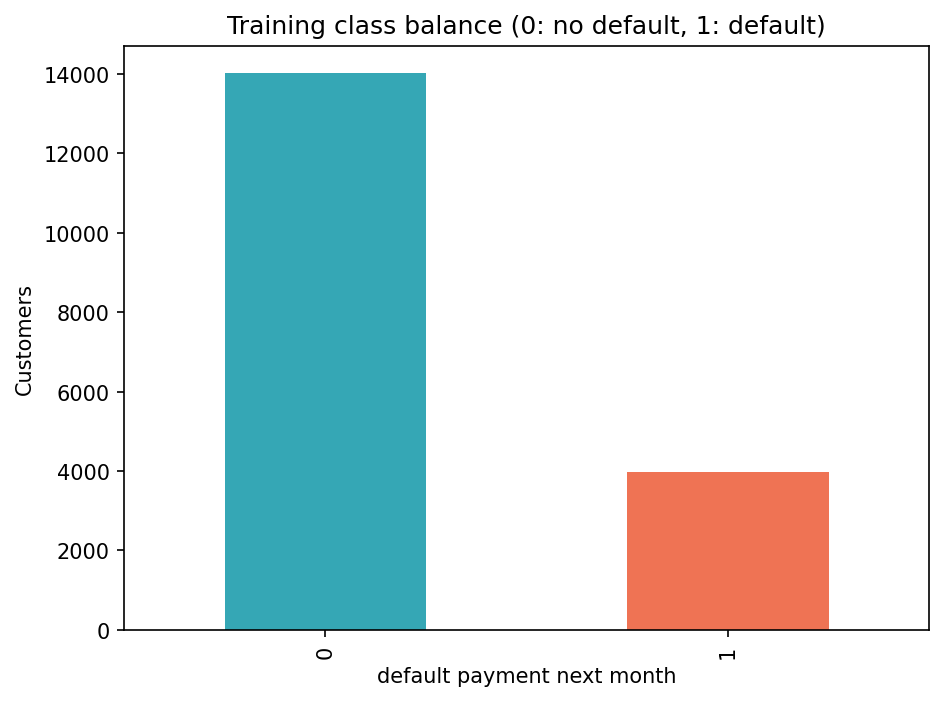

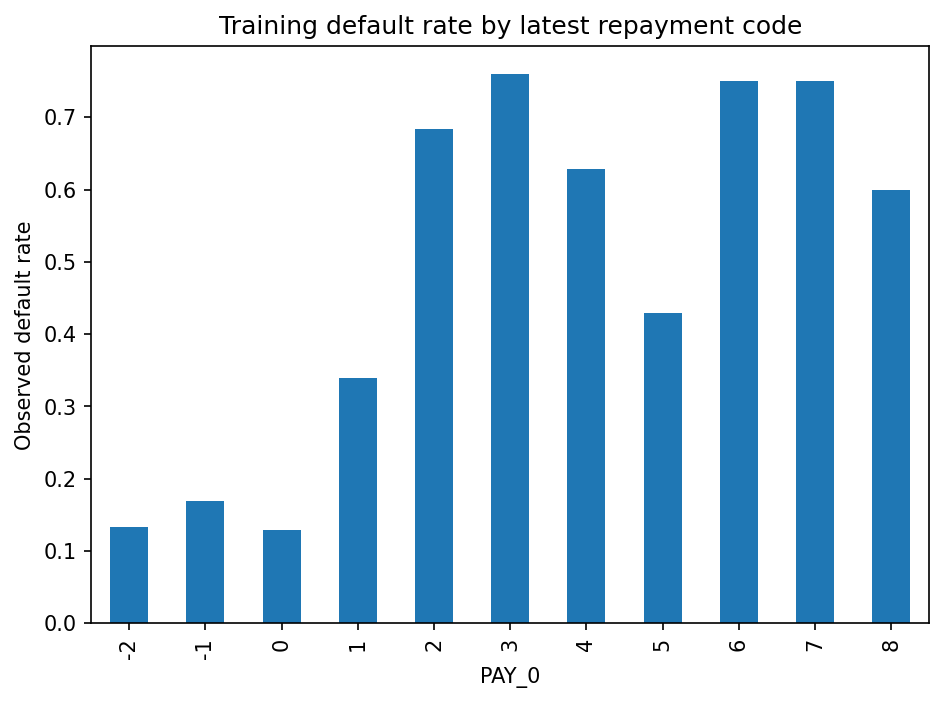

In [2]:
validation = json.loads((ROOT / 'reports/data_validation.json').read_text())
print('Missing cells:', validation['missing_cells'])
print('Negative bill cells:', validation['negative_bill_cells'])
display(training[['LIMIT_BAL', TARGET]].describe())
display(Image(filename=str(ROOT / 'reports/figures/class_balance.png')))
display(Image(filename=str(ROOT / 'reports/figures/delinquency_default_rate.png')))

## Feature engineering
All features use April–September observations available before the target month. Utilization is statement balance / limit, not a full measure of all credit exposure. Payment/bill ratios are same-month behavior proxies, not exact fractions of settled statements. Positive bill denominators only, zero otherwise, capped at 10. Slopes reverse September→April into chronological order and divide by limit.

In [3]:
features = engineer(training[RAW_FEATURES])
display(features[['utilization_recent', 'payment_bill_ratio_mean', 'delinquency_frequency', 'bill_trend_per_limit']].describe())
print('Raw deployed inputs:', len(RAW_FEATURES), '| Engineered matrix columns:', features.shape[1])

Raw deployed inputs: 19 | Engineered matrix columns: 34


,utilization_recent,payment_bill_ratio_mean,delinquency_frequency,bill_trend_per_limit
count,17998.000000,17998.000000,17998.000000,17998.000000
mean,0.419689,0.499029,0.833481,0.022444
std,0.411680,0.774826,1.552295,0.062962
min,-0.619892,0.000000,0.000000,-0.307312
25%,0.020911,0.039130,0.000000,-0.005825
50%,0.302082,0.075161,0.000000,0.001505
75%,0.825303,0.721913,1.000000,0.036987
max,6.455300,5.773167,6.000000,0.753938


## Selection without test leakage
Three-fold grouped CV tunes average precision. A separate calibration partition fits sigmoid/isotonic variants. Raw validation AP compares model families; validation Brier chooses calibration, with log loss and reliability retained as separate diagnostics. V2 audits the executed V1 validation artifacts and retains Random Forest without retraining. Validation calibrated PD Q25/Q75 define descriptive segments independently of the review threshold. Threshold minimizes illustrative `5 × missed defaults + false flags` on validation. The test set has no selection role.

In [4]:
display(pd.read_csv(ROOT / 'reports/v2_selection_audit.csv'))
metadata = json.loads((ROOT / 'models/metadata.json').read_text())
print('Final model:', metadata['selected_model'], '| Calibration:', metadata['calibration'])
print('Frozen threshold:', metadata['threshold'], '| Segments:', metadata['segments'])

Final model: Random Forest | Calibration: sigmoid
Frozen threshold: 0.15 | Segments: {'low_upper_exclusive': 0.09535463063665424, 'high_lower_inclusive': 0.21843748706391583}


,model,raw_validation_ap,raw_validation_roc_auc,calibration,selected_brier,selected_log_loss,calibrated_validation_ap
0,Logistic Regression,0.552627,0.772385,sigmoid,0.133134,0.428968,0.552627
1,Random Forest,0.565882,0.782844,sigmoid,0.131843,0.424513,0.565882
2,XGBoost,0.561931,0.787064,isotonic,0.131740,0.444009,0.544854


## Executed held-out results
PR-AUC is average precision (AP). Comparator thresholds are 0.5; the selected model uses its separately frozen threshold. Read ROC/AP for ranking comparisons. Precision/recall and cost depend on threshold.

,model,calibration,roc_auc,pr_auc_ap,precision,recall,f1,brier,log_loss,threshold,tn,fp,fn,tp,cost_per_customer,n
0,Logistic Regression,sigmoid,0.773637,0.551252,0.687776,0.352453,0.466068,0.135324,0.432514,0.50,4459,212,858,467,0.750834,5996
1,Random Forest,sigmoid,0.783971,0.567195,0.419263,0.670189,0.515829,0.134372,0.429845,0.15,3441,1230,437,888,0.569546,5996
2,XGBoost,isotonic,0.782258,0.540508,0.658915,0.384906,0.485946,0.135212,0.473300,0.50,4407,264,815,510,0.723649,5996


,split,segment,n,observed_default_rate,mean_predicted_pd
0,validation,HIGH,750,0.518667,0.515109
1,validation,LOW,749,0.069426,0.085245
2,validation,MEDIUM,1498,0.147530,0.130021
3,test,HIGH,1544,0.498057,0.498956
4,test,LOW,1414,0.052334,0.084846
5,test,MEDIUM,3038,0.158657,0.129637


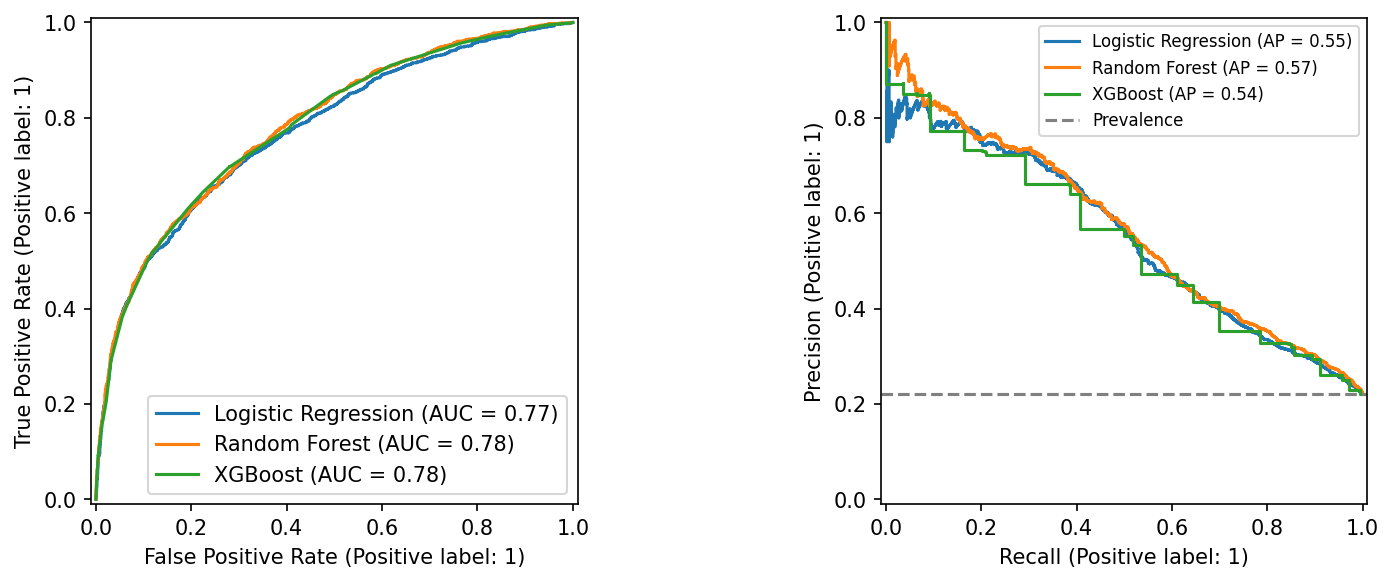

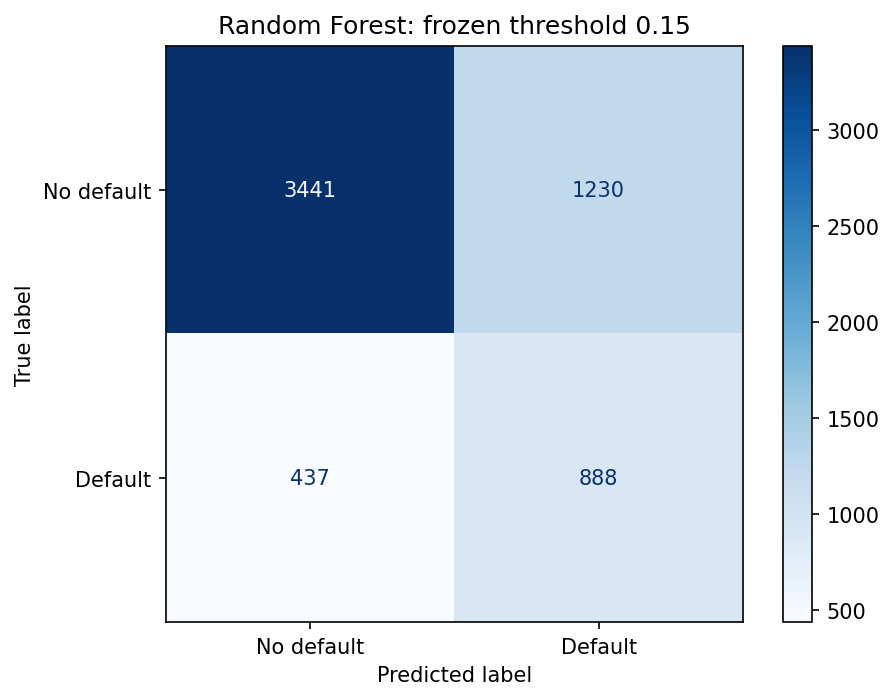

In [5]:
display(pd.read_csv(ROOT / 'reports/test_model_comparison.csv'))
display(pd.read_csv(ROOT / 'reports/risk_segments.csv'))
display(Image(filename=str(ROOT / 'reports/figures/model_curves.png')))
display(Image(filename=str(ROOT / 'reports/figures/confusion_matrix.png')))

## Explanations and fairness
SHAP explains the underlying model, not the calibrated probability. Correlated engineered features share importance; attribution is not causation. Excluding demographics does not eliminate proxy discrimination. Small denominators are suppressed; Wilson rate intervals for sufficiently sized groups approximate independent records and omit selection/clustering uncertainty; audit rates are descriptive, not fairness certification.

,Unnamed: 0,mean_absolute_shap
0,severe_delinquency_months,0.032036
1,max_delay,0.027710
2,delinquency_frequency,0.025327
3,PAY_0_2.0,0.016580
4,PAY_2_2.0,0.011342
5,PAY_0_0.0,0.010993
6,recent_delay_change,0.006175
7,PAY_AMT1,0.005785
8,utilization_mean,0.005518
9,LIMIT_BAL,0.005356


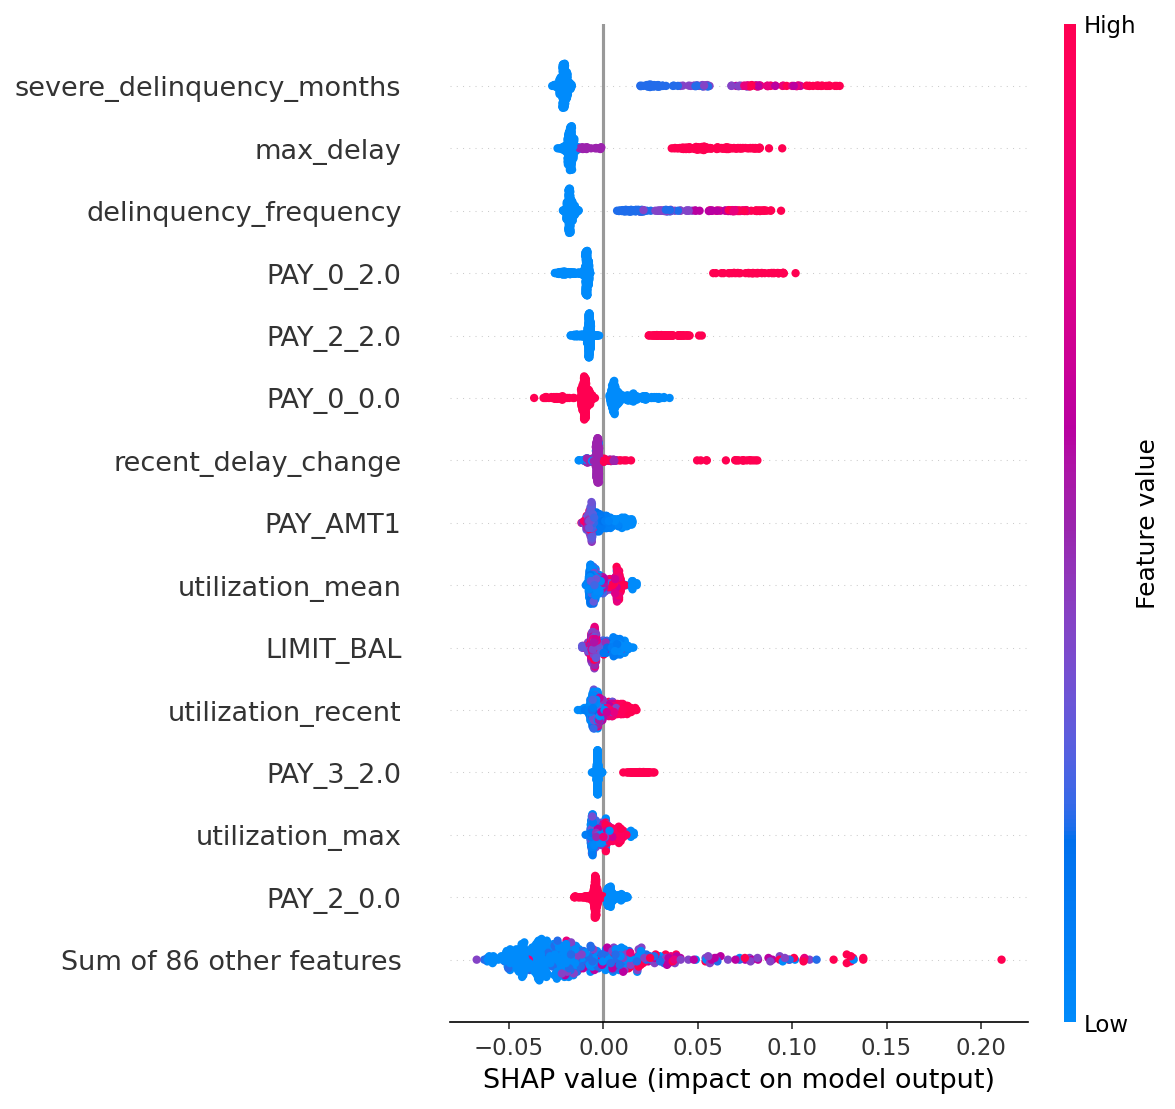

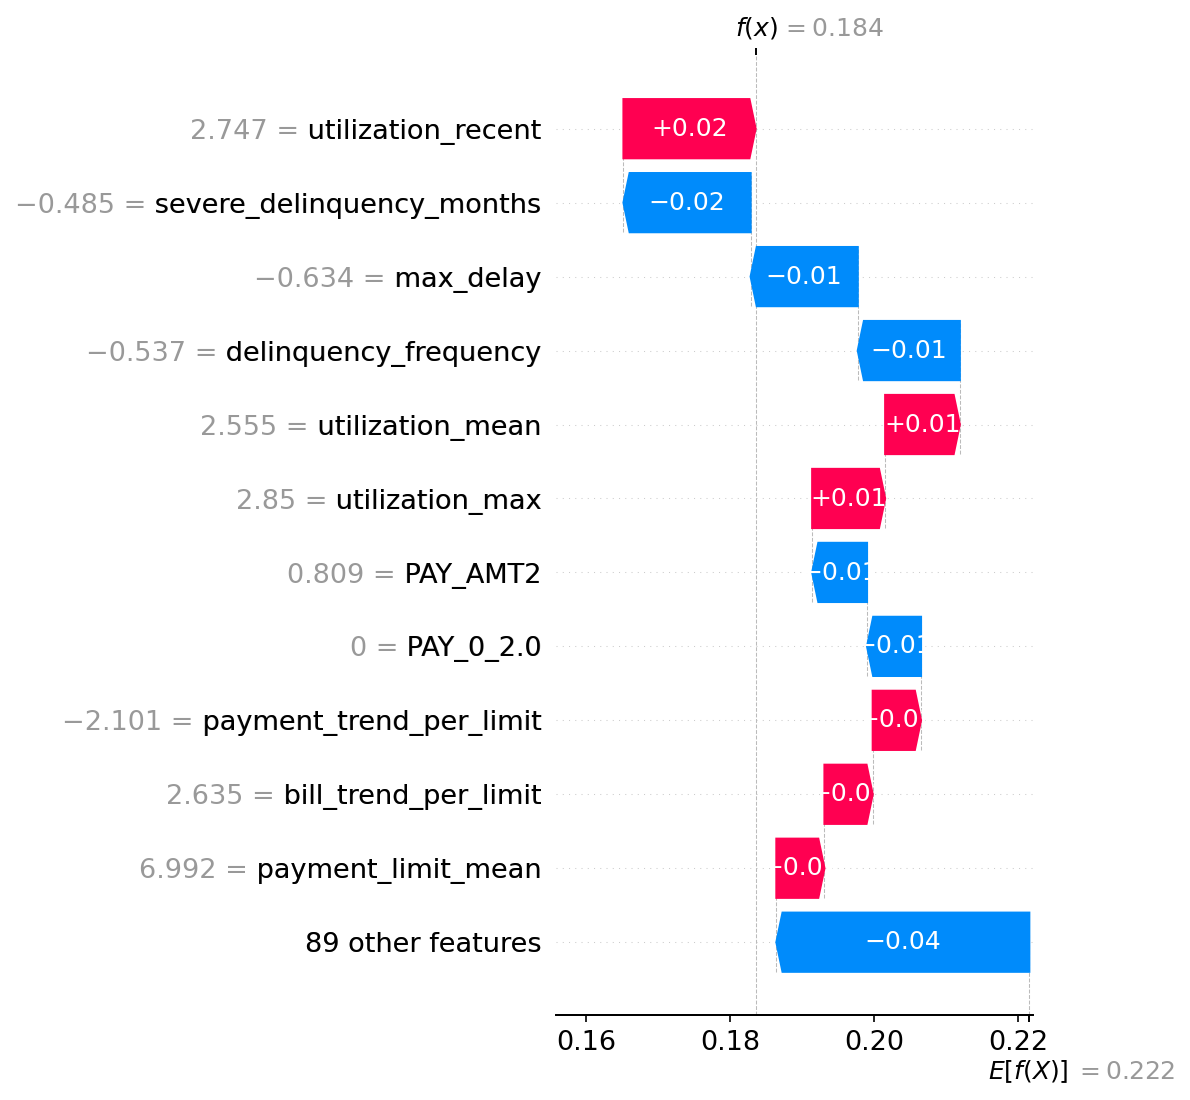

,attribute,group,n,positive_n,negative_n,small_group,brier,mean_predicted_pd,calibration_gap,default_rate,default_rate_ci95_lower,default_rate_ci95_upper,flag_rate,flag_rate_ci95_lower,flag_rate_ci95_upper,tpr,tpr_ci95_lower,tpr_ci95_upper,fpr,fpr_ci95_lower,fpr_ci95_upper
0,SEX,2,3657,754,2903,False,0.130665,0.209644,0.003464,0.206180,0.193379,0.219597,0.345912,0.330664,0.361483,0.653846,0.619186,0.686947,0.265932,0.250176,0.282306
1,SEX,1,2339,571,1768,False,0.140169,0.221260,-0.022861,0.244121,0.227142,0.261940,0.364686,0.345416,0.384400,0.691769,0.652718,0.728257,0.259050,0.239166,0.279978
2,EDUCATION,2,2837,687,2150,False,0.143590,0.227039,-0.015118,0.242157,0.226749,0.258263,0.368699,0.351135,0.386619,0.668122,0.632061,0.702314,0.273023,0.254609,0.292247
3,EDUCATION,3,970,249,721,False,0.153943,0.236853,-0.019848,0.256701,0.230209,0.285112,0.397938,0.367596,0.429085,0.670683,0.610103,0.726076,0.303745,0.271290,0.338279
4,EDUCATION,1,2107,377,1730,False,0.113417,0.188922,0.009994,0.178927,0.163150,0.195873,0.318462,0.298915,0.338670,0.687003,0.638506,0.731727,0.238150,0.218673,0.258788
5,EDUCATION,4,19,1,18,True,0.052425,0.110806,0.058175,0.052632,NaN,NaN,0.052632,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,EDUCATION,6,11,5,6,True,0.293099,0.191051,-0.263494,0.454545,NaN,NaN,0.363636,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,EDUCATION,5,48,6,42,True,0.120138,0.159157,0.034157,0.125000,NaN,NaN,0.208333,NaN,NaN,NaN,NaN,NaN,0.214286,NaN,NaN
8,EDUCATION,0,4,0,4,True,0.012036,0.108486,0.108486,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,MARRIAGE,2,3144,643,2501,False,0.129352,0.209617,0.005101,0.204517,0.190782,0.218972,0.350509,0.334023,0.367360,0.668740,0.631453,0.704023,0.268693,0.251684,0.286410


In [6]:
display(pd.read_csv(ROOT / 'reports/shap_importance.csv').head(10))
display(Image(filename=str(ROOT / 'reports/figures/shap_summary.png')))
display(Image(filename=str(ROOT / 'reports/figures/individual_explanation.png')))
display(pd.read_csv(ROOT / 'reports/fairness_audit.csv'))

## Interview discussion
1. Why AP rather than accuracy? Defaults are the minority; AP describes precision across recall.
2. Why four partitions? Fitting, calibration, model/threshold selection and independent evaluation have different roles.
3. Why did Random Forest win? Its validation AP was highest, even though XGBoost had higher validation ROC-AUC.
4. Why no SMOTE? Preserve the observed event rate for probability estimation; tune the operating threshold instead.
5. What is missing for real lending? Current representative data, temporal validation, governance, broader fairness analysis with clustering-aware uncertainty, security, exposure-at-default/LGD and policy review.

Read `reports/model_card.md`, `reports/v2_verification_report.md` and the README for exact results and execution limits.